# Implied Vol Fit

Author: Sebastien Gurrieri, sebgur@gmail.com

This notebook illustrates the implied vol functionalities in the SDevPy library. In its current state, it uses as example the first model in [[Gurrieri 2010]](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1779463).

Named 'TsSvi1' for "Term-Structure SVI 1", this model is essentially the original SVI model by J. Gatheral at each expiry, but where the SVI parameters are parametric functions of time. It is thus a global model for the implied vol surface, calibrated to all options at once. For more details on the properties of this model, see reference above.

In [14]:
import datetime as dt
import numpy as np
from platform import python_version
import matplotlib.pyplot as plt
import sdevpy as sd
from sdevpy.market import eqvolsurface as vsurf
from sdevpy.volatility.impliedvol.models.tssvi1 import TsSvi1
from sdevpy.volatility.impliedvol.models.tssvi2 import TsSvi2
from sdevpy.volatility.impliedvol.models.logmix import LogMix
from sdevpy.volatility.impliedvol.impliedvol_calib import TsIvCalibrator
from sdevpy.volatility.localvol.dupire import calib_lv_dupire
from sdevpy.utilities import timegrids
from sdevpy.maths.metrics import rmse
from sdevpy.utilities.algos import upper_bound


print("Python version: " + python_version())
print("NumPy version: " + np.__version__)
print("SDevPy version: " + sd.__version__)

Python version: 3.14.0
NumPy version: 2.3.5
SDevPy version: 1.0.5


### Retrieve market data
The SDevPy library has a set of minimalistic market data files containing sample data. Beware that it contains toy data only, to be used strictly for illustration purposes. The data necessary for fitting, which is the expiries, the forwards, the strikes and the volatilities, are all contained in 1 file (per valuation date) and retrieved in an object (dictionary). The user can use the model simply by re-creating that object from their own data.

In [2]:
name = "ABC"
valdate = dt.datetime(2025, 12, 15)

# Retrieve market option data object
file = vsurf.data_file(name, valdate)
mkt_data = vsurf.eqvolsurfacedata_from_file(file)
print(f"Retrieved market data from file {file}")

# Access data in object
expiries = mkt_data.expiries
fwds = mkt_data.forwards
strikes = mkt_data.get_strikes('absolute')
mkt_vols = mkt_data.vols

# Quick check of size consistency
print(f"Number of expiries: {len(expiries)}")
print(f"Number of forwards: {len(fwds)}")
print(f"Number of strike sections: {len(strikes)}")
print(f"Number of vol sections: {len(mkt_vols)}")
for i in range(len(expiries)):
    print(f"Expiry {i+1} number of strikes/vols: {len(strikes[i])}/{len(mkt_vols[i])}")

Retrieved market data from file C:\Code\SDev.Python\datasets\marketdata\eqoptions\ABC\20251215-000000.json
Number of expiries: 6
Number of forwards: 6
Number of strike sections: 6
Number of vol sections: 6
Expiry 1 number of strikes/vols: 5/5
Expiry 2 number of strikes/vols: 5/5
Expiry 3 number of strikes/vols: 5/5
Expiry 4 number of strikes/vols: 5/5
Expiry 5 number of strikes/vols: 5/5
Expiry 6 number of strikes/vols: 5/5


In [15]:
# Initialize model
iv_surface = LogMix(2)
# iv_surface = TsSvi1()

# Calibrate model
calibrator = TsIvCalibrator(iv_surface, {'optimizer': 'SLSQP', 'tol': 1e-6})
calibrator.calibrate(mkt_data)

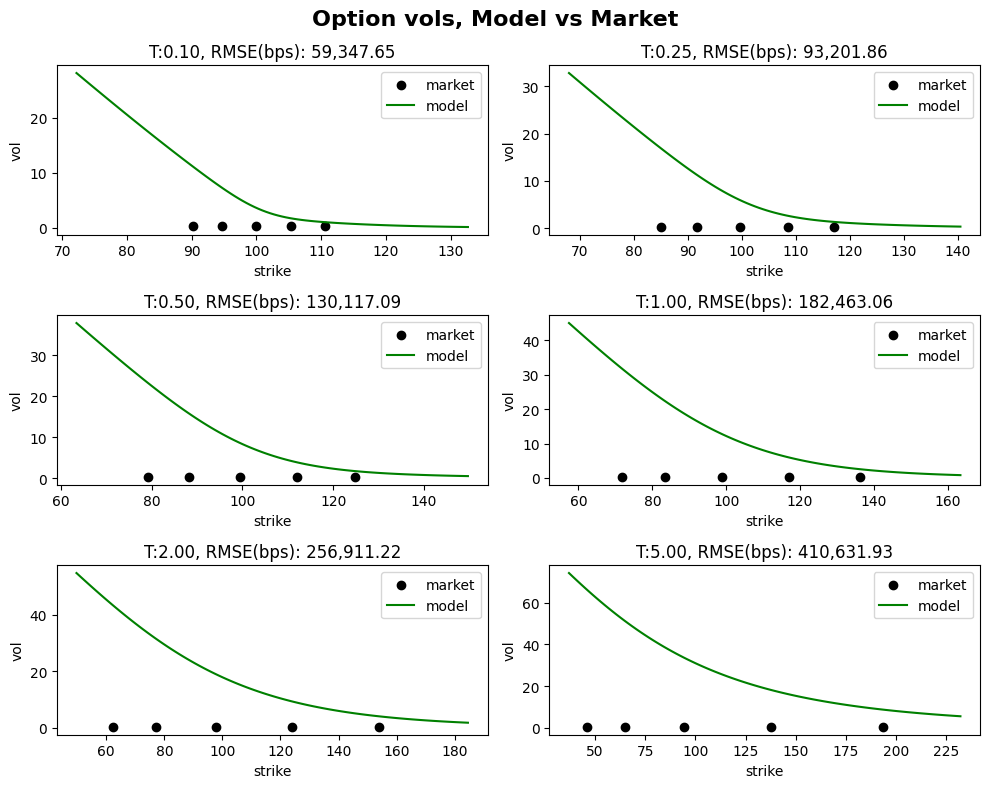

In [16]:
# Estimate model on points and calculate RMSE, plot comparison
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = timegrids.model_time(valdate, expiries[exp_idx])
        fwd = fwds[exp_idx]
        exp_strikes = strikes[exp_idx]
        min_k, max_k = exp_strikes[0], exp_strikes[-1]
        m_strikes = np.linspace(0.8 * min_k, 1.2 * max_k, 100)
        m_vols = iv_surface.calculate(expiry, m_strikes, True, fwd)
        ax.scatter(exp_strikes, mkt_vols[exp_idx], label="market", color='black')
        ax.plot(m_strikes, m_vols, label="model", color='green')
        model_vols = iv_surface.calculate(expiry, exp_strikes, True, fwd)
        vol_rmse = rmse(mkt_vols[exp_idx], model_vols)
        ax.set_title(f"T:{expiry:.2f}, RMSE(bps): {10000.0 * vol_rmse:,.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('vol')
        ax.legend()

fig.suptitle('Option vols, Model vs Market', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Local Vol Calibration (Dupire)
Now we use the implied volatility surface calibrated to market data in the previous section to derive the corresponding local volatility using the Dupire method.

In [17]:
# Retrieve calibration horizon
tmax = timegrids.model_time(valdate, expiries.max())

# Launch Dupire calibration
lv_calib = calib_lv_dupire(iv_surface, points_per_year=10, tmax=tmax)
t = lv_calib['t_grid']
moneyness = lv_calib['moneyness']
lv = lv_calib['lv']

[0.         0.10209673 0.20419346 0.30629019 0.40838692 0.51048365
 0.61258037 0.7146771  0.81677383 0.91887056 1.02096729 1.12306402
 1.22516075 1.32725748 1.42935421 1.53145094 1.63354767 1.73564439
 1.83774112 1.93983785 2.04193458 2.14403131 2.24612804 2.34822477
 2.4503215  2.55241823 2.65451496 2.75661169 2.85870841 2.96080514
 3.06290187 3.1649986  3.26709533 3.36919206 3.47128879 3.57338552
 3.67548225 3.77757898 3.87967571 3.98177244 4.08386916 4.18596589
 4.28806262 4.39015935 4.49225608 4.59435281 4.69644954 4.79854627
 4.900643   5.00273973]


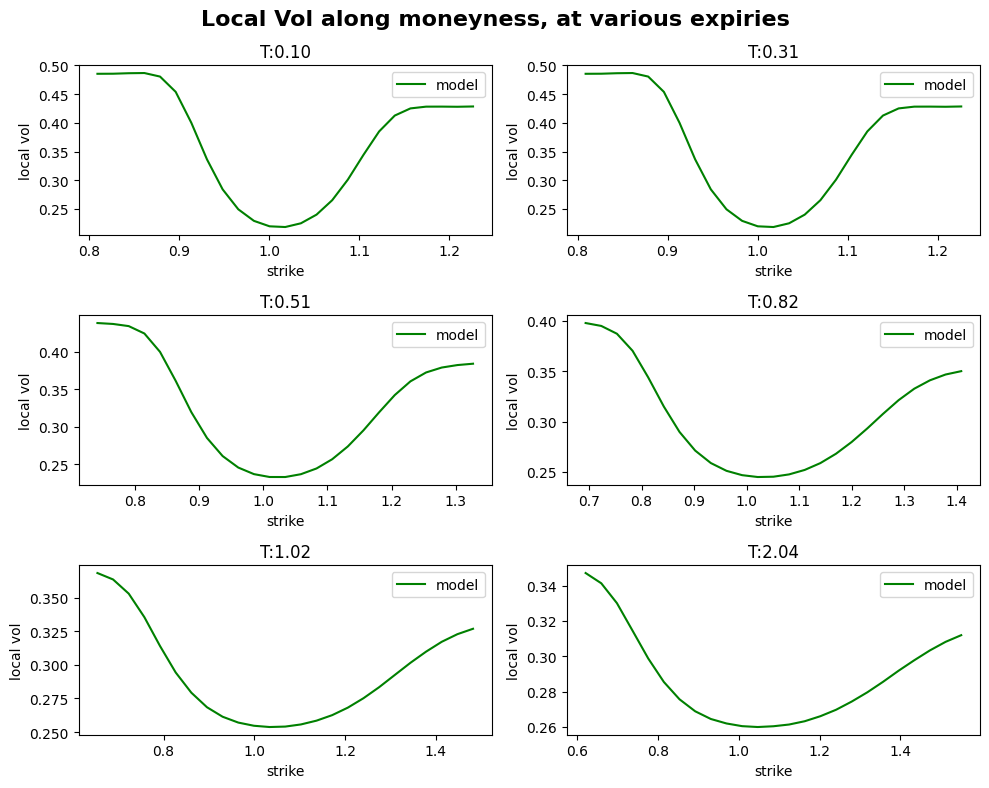

In [20]:
# View the LV along the strike at several expiries
t_plot = [1.0 / 12.0, 0.25, 0.5, 0.75, 1.0, 2.0]
t_idx = [upper_bound(t, tp) for tp in t_plot]
t_plot = t[t_idx]

n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = t_plot[exp_idx]
        ax.plot(moneyness[exp_idx], lv[exp_idx], label="model", color='green')
        ax.set_title(f"T:{expiry:.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('local vol')
        ax.legend()

fig.suptitle('Local Vol along moneyness, at various expiries', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

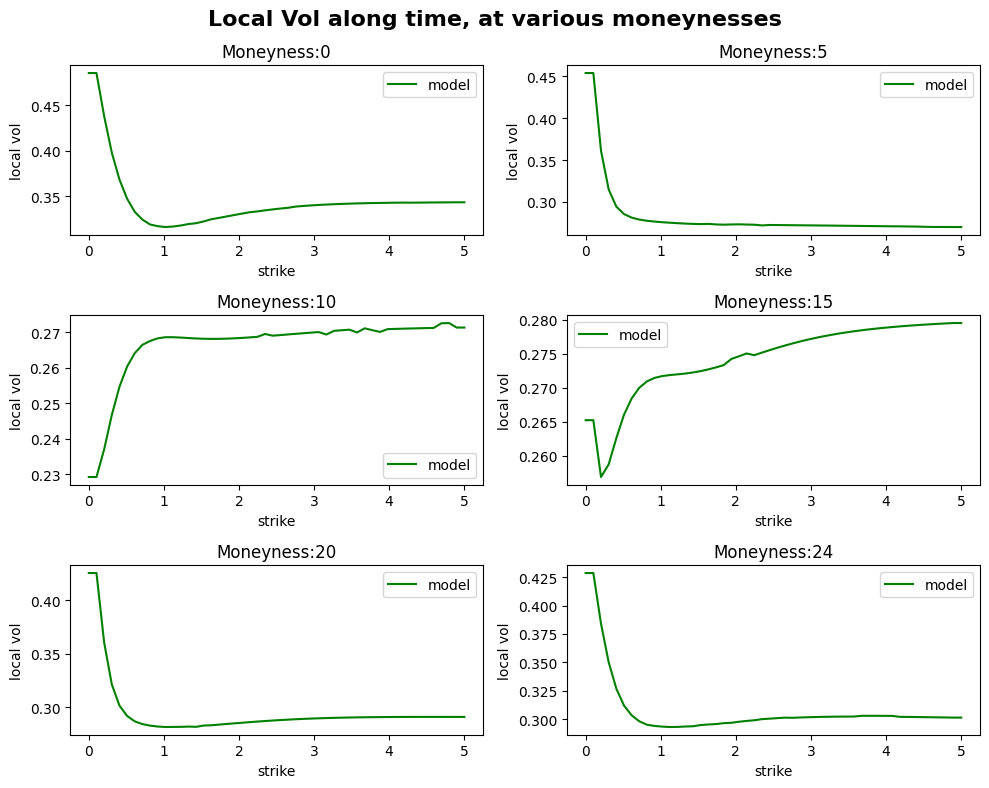

In [19]:
# View LV along the expiry at several moneynesses
m_idx = [0, 5, 10, 15, 20, 24]
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        k_idx = n_cols * i + j
        k_idx = m_idx[k_idx]
        # k = moneyness[k_idx]
        lv_ = [lv[tidx][k_idx] for tidx in range(len(t))]
        ax.plot(t, lv_, label="model", color='green')
        ax.set_title(f"Moneyness:{k_idx}")
        ax.set_xlabel('strike')
        ax.set_ylabel('local vol')
        ax.legend()

fig.suptitle('Local Vol along time, at various moneynesses', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### Compare against MC prices

In [ ]:
from sdevpy.utilities import book as bk
from sdevpy.montecarlo.payoffs.vanillas import make_vanilla_option
from sdevpy.montecarlo.payoffs import cashflows as cfl
from sdevpy.montecarlo.payoffs.basic import Trade, Instrument
from sdevpy.montecarlo.mcpricer import price_book

# Create portfolio
option_type = 'Call'
trades = []
strikes = mkt_data.get_strikes('absolute')
for exp_idx, expiry in enumerate(expiries):
    exp_strikes = strikes[exp_idx]
    for strike in exp_strikes:
        index = make_vanilla_option(name, strike, option_type, expiry)
        cf = cfl.Cashflow(index, expiry)
        trades.append(Trade(Instrument(cashflow_legs=[[cf]])))

# Create book
book = bk.Book()
book.add_trades(trades)

# Price book
mc_price = price_book(valdate, book, constr_type='brownianbridge', rng_type='sobol',
                      n_paths=10000, n_timesteps=50)

for i in range(len(mc_price['pv'])):
    print("MC:", mc_price['pv'][i])

Runtime(Generate spot paths): 0.1s
Runtime(Interpolate to event grid): 0.0s
Runtime(Payoff calculation): 0.0s
MC: 9.942346141046107
MC: 6.009689157130305
MC: 2.593421908308448
MC: 0.7434543790747832
MC: 0.15638528817953676
MC: 15.453227386197993
MC: 9.449217260741078
MC: 4.072073512516559
MC: 1.1320797766289996
MC: 0.21076214454326234
MC: 21.569878353703185
MC: 13.645879028011606
MC: 6.281217587542939
MC: 1.9293881932015524
MC: 0.44413111216622797
MC: 29.806581516024956
MC: 19.512460131714636
MC: 9.396313710812361
MC: 3.0576438902644636
MC: 0.7525743422480318
MC: 40.62291087278166
MC: 27.788306274851976
MC: 14.194804475458495
MC: 4.995413794826417
MC: 1.2968243442218832
MC: 58.79761388429849
MC: 43.631848888173685
MC: 24.986855388569904
MC: 10.078619654190087
MC: 3.0173797081875344


### Compare against PDE prices